In [57]:
import numpy as np
from matplotlib import pyplot as plt

import tidy3d as td
from tidy3d.plugins import waveguide
import tidy3d.web as web
# Simulation wavelength.
wl = 1.55  # Central simulation wavelength (um).
bw = 0.1  # Simulation bandwidth (um).
n_wl = 21  # Number of wavelength points within the bandwidth.
# feat
wl_max = wl + bw / 2
wl_min = wl - bw / 2
wl_range = np.linspace(wl_min, wl_max, n_wl)
freq = td.C_0 / wl
freqs = td.C_0 / wl_range
freqw = 0.5 * (freqs[0] - freqs[-1])

# material libary
eff_inf = 100
n_sio2 = 1.444  # silicon oxide refractive index at 1550 nm
sio2 = td.Medium(permittivity=n_sio2**2)
air = td.Medium(permittivity=1)



ln_no_coeffs = [(2.6734, 0.01764), (1.2290, 0.05914), (12.614, 474.60)]
ln_ne_coeffs = [(2.6734, 0.01764),  (1.2290, 0.05914),  (12.614, 474.60)]
ln_no= td.Sellmeier(coeffs=ln_no_coeffs)
ln_ne= td.Sellmeier(coeffs=ln_ne_coeffs)

ln = td.AnisotropicMedium(xx=ln_no, yy=ln_ne, zz=ln_no)


Hc=0.250
Hs=0.150

l=5
w1=1
w2=0.7
gap=0.4
angle=20*np.pi/180
length_buffer=0.5
size_y=w1*2+gap+wl*2
size_x=length_buffer*2+l

vertices1 =[(0,gap/2),(0,gap/2+w1),(l,gap/2+w2),(l,gap/2)]
vertices2 =[(0,-gap/2),(0,-gap/2-w2),(l,-gap/2-w1),(l,-gap/2)]
wg_top = td.Structure(geometry=td.PolySlab(vertices=vertices1, axis=2, slab_bounds=(-Hc / 2, Hc / 2),sidewall_angle=angle,reference_plane="top"), medium=ln)
wg_bot = td.Structure(geometry=td.PolySlab(vertices=vertices2, axis=2, slab_bounds=(-Hc / 2, Hc / 2),sidewall_angle=angle,reference_plane="top"), medium=ln)



# ln input port
ln_wg1 = td.Structure(
    geometry=td.PolySlab(vertices=[(-eff_inf,gap/2+w1),(0,gap/2+w1),(0,gap/2),(-eff_inf,gap/2)], axis=2, slab_bounds=(-Hc / 2, Hc / 2),sidewall_angle=angle,reference_plane="top"),
    medium=ln,
)
ln_wg2 = td.Structure(
    geometry=td.PolySlab(vertices=[(l,-gap/2),(l,-gap/2-w1),(eff_inf,-gap/2-w1),(eff_inf,-gap/2)], axis=2, slab_bounds=(-Hc / 2, Hc / 2),sidewall_angle=angle,reference_plane="top"),
    medium=ln,
)



# ln slab
ln_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -size_y/2, -Hc/2-Hs),
        rmax=(eff_inf, size_y/2, -Hc/2),
    ),
    medium=ln,
)


# sio2 slab
sio2_substrate = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -size_y/2, -eff_inf),
        rmax=(eff_inf, size_y/2, -Hc/2-Hs),
    ),
    medium=sio2,
)


Structures=[wg_top,wg_bot,ln_wg1,ln_wg2,ln_substrate,sio2_substrate]





00:32:47 KST WARNING: Structure at 'structures[4]' has bounds that extend       
             exactly to simulation edges. This can cause unexpected behavior. If
             intending to extend the structure to infinity along one dimension, 
             use td.inf as a size variable instead to make this explicit.       

             WARNING: Suppressed 3 WARNING messages.                            

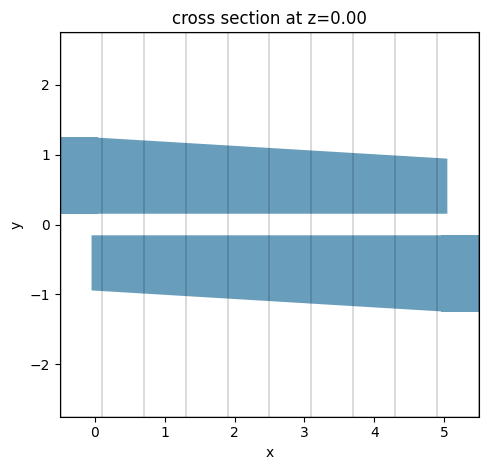

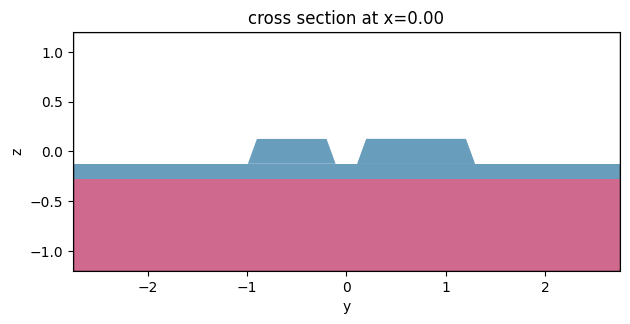

In [58]:



eme_grid_spec = td.EMEExplicitGrid(
    boundaries=[0, l],
    mode_specs=[
        td.EMEModeSpec(num_modes=2),
        td.EMEModeSpec(num_modes=4),
        td.EMEModeSpec(num_modes=2)
    ]
)

eme_grid_spec = td.EMEUniformGrid(
    num_cells=10,
    mode_spec=td.EMEModeSpec(num_modes=2)
)

eme_field_mon = td.EMEFieldMonitor(
    name="field", 
    size=(td.inf, td.inf,0)
)

lengths = np.linspace(l, 40*l, 100)

eme_sim = td.EMESimulation(
    center=(l/2, 0, 0),
    size=(size_x, size_y, Hc+Hs+2),
    structures=Structures,
    medium=air,
    symmetry=(0, 0, 0),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=10,wavelength= wl),
    monitors=[eme_field_mon],
    eme_grid_spec=eme_grid_spec,
    freqs=freq,
    axis=0,
    port_offsets=(0, 0),
    sweep_spec=td.EMELengthSweep(scale_factors=list(lengths / l))
)
#,ln_wg1,ln_wg2,ln_substrate,sio2_substrate
_ = eme_sim.plot(z=0, monitor_alpha=0)
plt.show()

_ = eme_sim.plot(x=0, monitor_alpha=0)
plt.show()


Now we run the simulation.

In [59]:
eme_sim_data = web.run(eme_sim, task_name="EME grating")

00:32:51 KST Created task 'EME grating' with task_id                            
             'eme-a8caa082-2505-4d12-a56b-d269a1876957' and task_type 'EME'.

             Tidy3D's EME solver is currently in the beta stage. Cost of EME    
             simulations is subject to change in the future.

/Users/hwanghyeon/pattern/tidy/lib/python3.11/site-packages/rich/live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

00:32:53 KST status = queued

             To cancel the simulation, use 'web.abort(task_id)' or              
             'web.delete(task_id)' or abort/delete the task in the web UI.      
             Terminating the Python script will not stop the job running on the 
             cloud.

...

00:33:47 KST status = success

00:33:50 KST loading simulation from simulation_data.hdf5

             WARNING: Structure at 'structures[4]' has bounds that extend       
             exactly to simulation edges. This can cause unexpected behavior. If
             intending to extend the structure to infinity along one dimension, 
             use td.inf as a size variable instead to make this explicit.       

             WARNING: Suppressed 3 WARNING messages.                            

             WARNING: Warning messages were found in the solver log. For more   
             information, check 'SimulationData.log' or use                     
             'web.download_log(task_id)'.                                       

### EME Simulation Results

We can visualize the field data recorded by the field monitor. The field data is indexed by `eme_port_index` and `mode_index` in order to specify which port and which mode are excited.

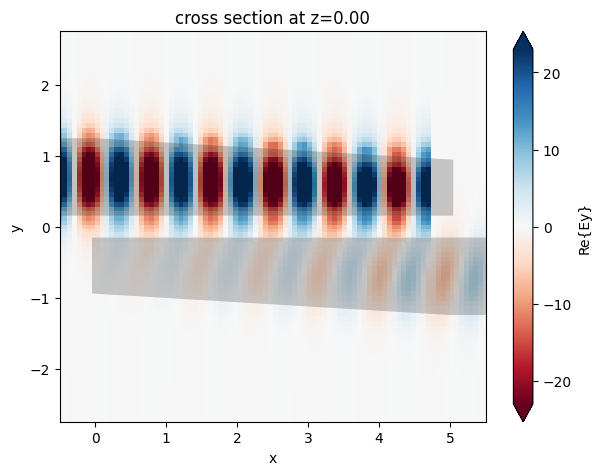

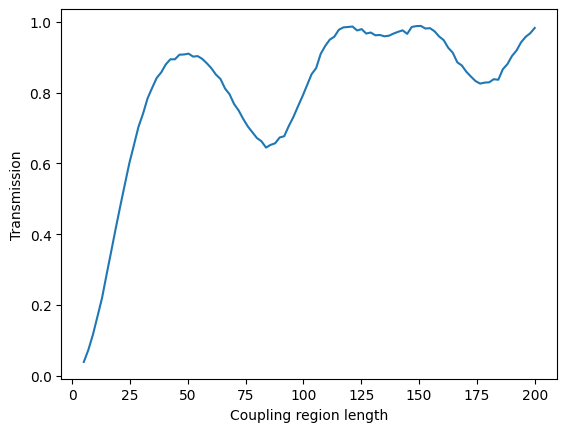

In [60]:
eme_sim_data.plot_field("field", "Ey", eme_port_index=0, mode_index=0)
plt.show()

transmission = eme_sim_data.smatrix.S21.isel(mode_index_in=0, mode_index_out=0, f=0).abs**2
plt.plot(lengths, transmission)
plt.xlabel('Coupling region length')
plt.ylabel('Transmission')
plt.show()


We can plot the transmission as a function of the length of the coupling region.

ValueError: x and y must have same first dimension, but have shapes (100,) and (1,)

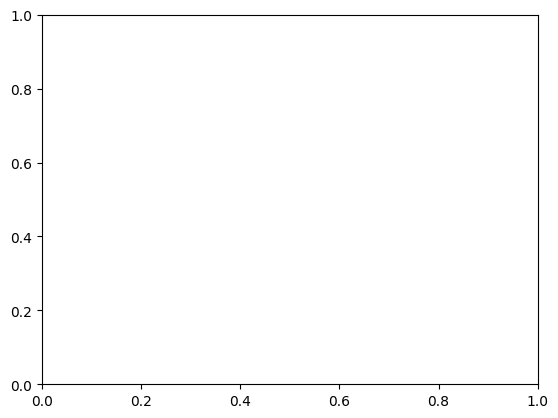

In [ ]:
transmission = eme_sim_data.smatrix.S21.isel(mode_index_in=0, mode_index_out=0, f=0).abs**2
plt.plot(lengths, transmission)
plt.xlabel('Coupling region length')
plt.ylabel('Transmission')
plt.show()

## Taper Edge Coupler

Next, we look at a taper edge coupler. Using the Tidy3D EME solver, we are able to simulate long tapers and perform length sweeps. See also this [notebook](https://www.flexcompute.com/tidy3d/examples/notebooks/EdgeCoupler/) where this taper and some variants are optimized using FDTD. The function to create the taper geometry is based on the work of [G. Ren et al. (2013)](https://www.sciencedirect.com/science/article/abs/pii/S0030401811006389)

### EME Simulation Setup

First, we define the materials and geometries.

In [ ]:
wl_c = 1.55  # Central wavelength.
freq0 = td.C_0 / wl_c

mat_si = td.Medium(permittivity=3.48**2)  # Taper and substrate material.
mat_sio2 = td.Medium(permittivity=1.44**2)  # Box and cladding material.
mat_air = td.Medium(permittivity=1.00)  # External medium material.

taper_l = 5  # Taper length.
taper_w_in = 0.19  # Taper tip width.
taper_w_out = 0.50  # Taper output width.
taper_t = 0.22  # Taper thickness.

box_thick = 3.0  # Silicon dioxide box layer.
clad_thick = 3.0  # Silicon dioxide layer covering the taper.

# Extra space around the taper at x,y directions.
pad_x = 1 * wl_c
pad_y = 1.5 * wl_c

# Large number to be used in replacement of td.inf when necessary.
_inf = 1e3

def get_taper(
    taper_shape="linear",
    init_coord=[pad_x, taper_w_in / 2],
    end_coord=[pad_x + taper_l, taper_w_out / 2],
):
    """Return a polygon composed of the taper vertices given the desired shape."""

    x0 = init_coord[0]
    x1 = end_coord[0]
    y0 = init_coord[1]
    y1 = end_coord[1]
    x = np.linspace(x0, x1, 41)

    tap_name = "linear_tap"
    if taper_shape == "quadratic":
        alpha = ((x - x0) / (x1 - x0)) ** 2
        tap_name = "quadratic_tap"
    elif taper_shape == "exponential":
        alpha = np.expm1((x - x0) / (x1 - x0)) / np.expm1(1)
        tap_name = "exponential_tap"
    elif taper_shape == "linear":
        alpha = (x - x0) / (x1 - x0)
    else:
        print(
            "taper_shape is neither 'linear', 'quadratic', or 'exponential'!\n"
            + "Linear taper shape returned!"
        )
        alpha = (x - x0) / (x1 - x0)

    y = y0 + alpha * (y1 - y0)
    upper_bound = [[xv, yv] for xv, yv in zip(x, y)] + [[_inf, y1]]
    lower_bound = [[_inf, -y1]] + [[xv, -yv] for xv, yv in zip(x[::-1], y[::-1])]
    taper_polygon = upper_bound + lower_bound

    # Inverted taper structure using a PolySlab.
    taper = td.Structure(
        geometry=td.PolySlab(
            vertices=taper_polygon, axis=2, slab_bounds=(-taper_t / 2, taper_t / 2)
        ),
        medium=mat_si,
        name=tap_name,
    )
    return taper

size_x = taper_l + 2 * pad_x
size_y = taper_w_out + 2 * pad_y
size_z = box_thick + clad_thick + taper_t

# Silicon dioxide box + cladding layers
sio2_medium = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(pad_x, -_inf, -_inf), rmax=(_inf, _inf, _inf)
    ),
    medium=mat_sio2,
)

# Simulation definition
taper_poly = get_taper(
    "linear",
    init_coord=[pad_x, taper_w_in / 2],
    end_coord=[size_x - pad_x, taper_w_out / 2],
)

Now we define the `eme_grid_spec` and `EMESimulation`. We use an `EMEUniformGrid`. It is important to use enough cells that the device profile does not change much in between each pair of cells. It can be necessary to experiment with different EME grids in order to make sure enough cells are used.

We set `store_port_modes=False` in the `EMESimulation` and `num_modes=1` in the `EMEFieldMonitor` to avoid downloading unnecessary data. We also add an `EMEModeSolverMonitor` and an `EMECoefficientMonitor` to help understand the simulation results.

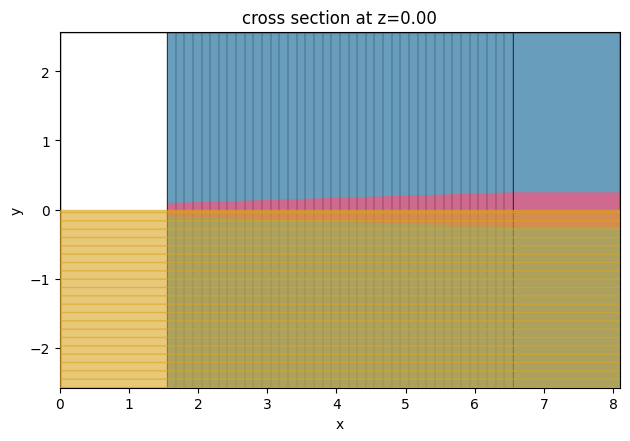

In [ ]:
eme_num_modes = 30

eme_grid_spec = td.EMEUniformGrid(
    num_cells=40,
    mode_spec=td.EMEModeSpec(num_modes=eme_num_modes)
)

eme_field_mon = td.EMEFieldMonitor(
    name="field", 
    size=(td.inf, td.inf, 0),
    num_modes=1
)

eme_mode_mon = td.EMEModeSolverMonitor(
    name="modes", 
    size=(td.inf, td.inf, td.inf),
    center=(pad_x, 0, 0),
    num_modes=9,
    eme_cell_interval_space=40
)

eme_coeff_mon = td.EMECoefficientMonitor(
    name="coeffs", 
    size=(td.inf, td.inf, td.inf),
)

lengths = np.linspace(1, 100, 30)

eme_sim = td.EMESimulation(
    center=(size_x / 2, 0, 0),
    size=(size_x, size_y, size_z),
    medium=mat_air,
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=15, wavelength=wl_c),
    structures=[sio2_medium, taper_poly],
    monitors=[eme_field_mon, eme_mode_mon, eme_coeff_mon],
    symmetry=(0, -1, 1),
    axis=0,
    freqs=[freq0],
    eme_grid_spec=eme_grid_spec,
    port_offsets=(pad_x, pad_x),
    store_port_modes=False,
    sweep_spec=td.EMELengthSweep(scale_factors=list(lengths / taper_l))
)

eme_sim.plot(z=0, monitor_alpha=0)
plt.show()

In [ ]:
eme_sim_data = web.run(eme_sim, task_name="EME taper")

10:24:21 BST Created task 'EME taper' with task_id                              
             'eme-4b397aa5-386e-45ba-9777-5d49703c3fb5' and task_type 'EME'.

             Tidy3D's EME solver is currently in the beta stage. Cost of EME    
             simulations is subject to change in the future.

Output()

10:24:23 BST status = queued

             To cancel the simulation, use 'web.abort(task_id)' or              
             'web.delete(task_id)' or abort/delete the task in the web UI.      
             Terminating the Python script will not stop the job running on the 
             cloud.

...

Output()

Output()

10:27:11 BST status = success

Output()

10:27:43 BST loading simulation from simulation_data.hdf5

We can plot the field to check that the results are sensible. Note that the field is shown on the original structure (length 5 um), but the field monitor is recording at `sweep_index=0` (length 1 um). This is why the coupling efficiency appears so low in the field plot.

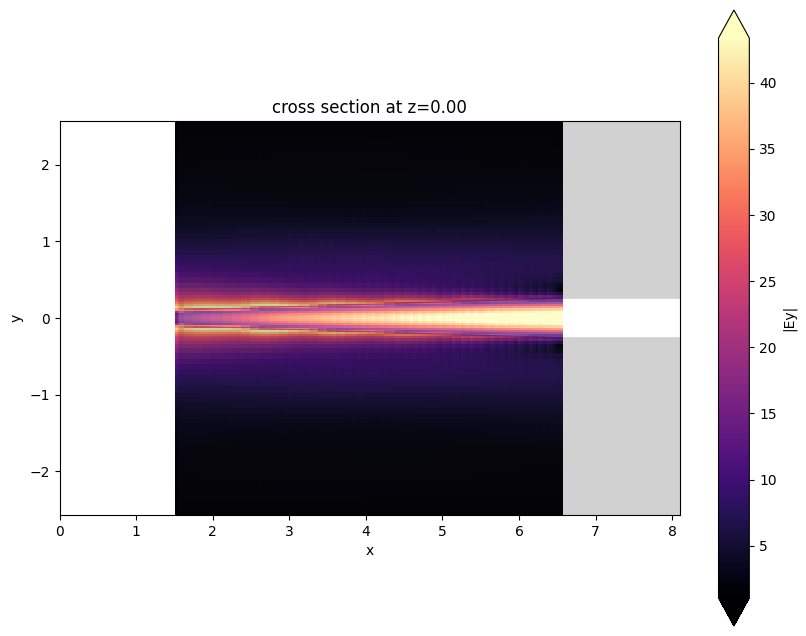

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
eme_sim_data.plot_field("field", "Ey", val="abs", eme_port_index=0, mode_index=0, ax=ax)
plt.show()

Now we plot the efficiency as a function of the taper length.

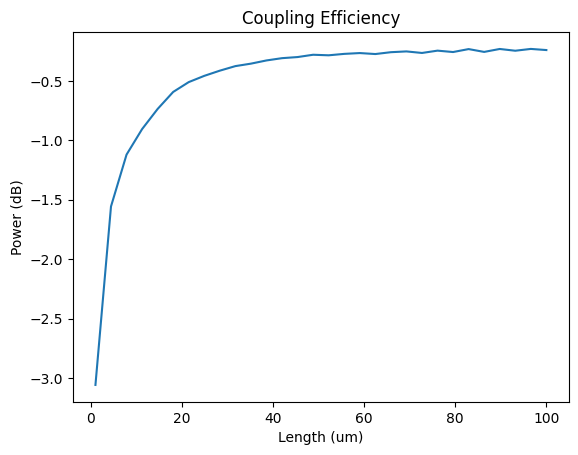

In [ ]:
eff = 20 * np.log10((eme_sim_data.smatrix.S21.isel(mode_index_in=0, mode_index_out=0)).abs.squeeze())
plt.plot(lengths, eff)
plt.xlabel("Length (um)")
plt.ylabel("Power (dB)")
plt.title("Coupling Efficiency")
plt.show()

We can inspect the EME modes, for example at the input port. We see that only one is guided. The remaining modes still contribute to EME propagation, capturing radiative losses and other effects.

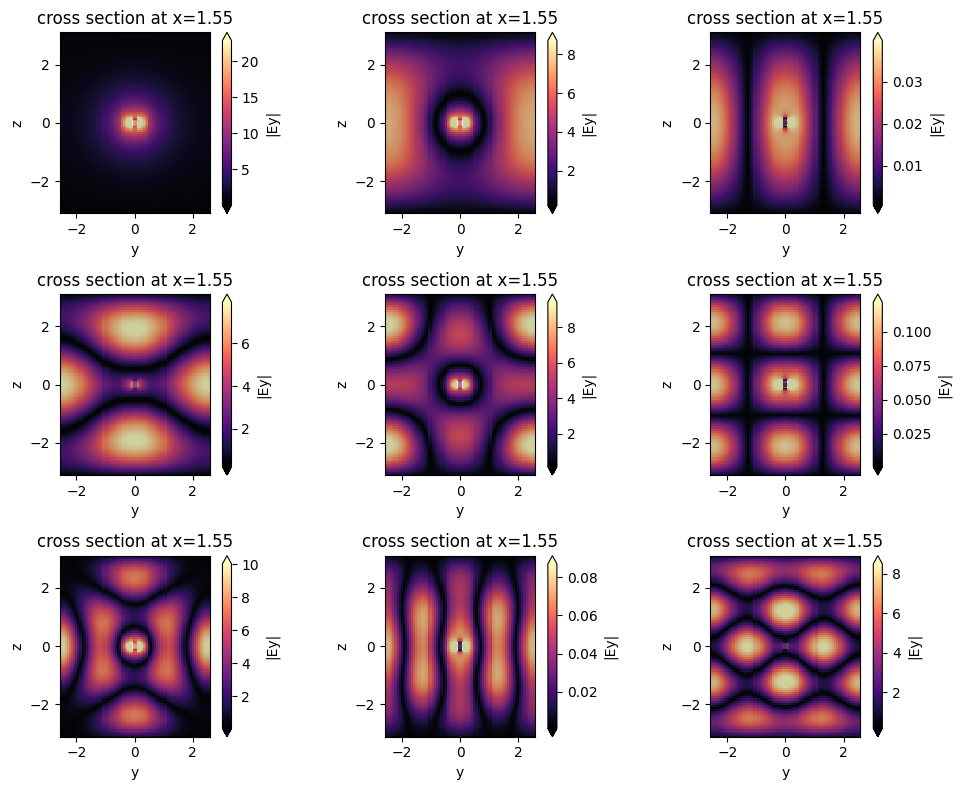

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(10, 8))
for mode_index in range(9):
    i = mode_index // 3
    j = mode_index % 3
    eme_sim_data.plot_field("modes", "Ey", val="abs", eme_cell_index=0, mode_index=mode_index, ax=ax[i][j])
plt.tight_layout()
plt.show()

We can also make a 2D plot of the scattering matrix as a function of cell index and mode index (although note that the coefficients are not normalized). This shows us that the scattering is occuring towards the beginning of the taper. Note that once again the default behavior of the monitor is to record at `sweep_index=0` (length 1 um).

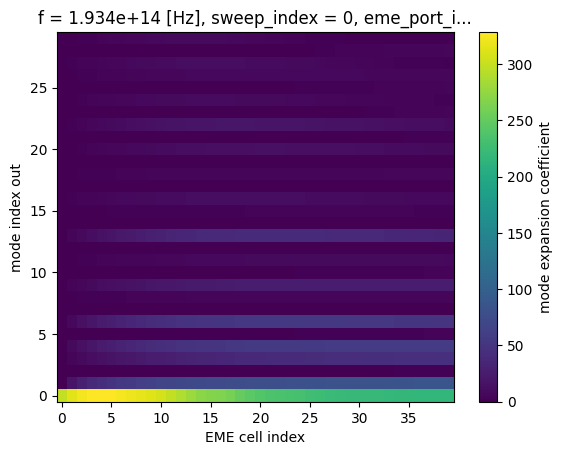

In [ ]:
eme_sim_data["coeffs"].A.sel(mode_index_in=0, eme_port_index=0).abs.plot(x="eme_cell_index")
plt.show()

## Tips and Tricks

### Other Bases

By default, the scattering matrix is expressed in the basis of EME modes at the two ports. It is sometimes useful to use alternative bases. For example, in a waveguide splitter, we might want the scattering matrix in the basis of modes of the individual waveguides. The functions `EMESimulationData.smatrix_in_basis` and `EMESimulationData.field_in_basis` can be used for this purpose after the simulation has been run.

### Frequency Sweeps

Frequency sweeps are supported by including multiple frequencies in the `freqs` field. However, our EME solver repeats the mode solving for each new frequency, so frequency sweeps involving a large number of frequencies can be slow and expensive. If a large number of frequencies are required, consider using our FDTD solver instead.

### Passivity and Unitarity Constraints

Passivity and unitarity constraints can be imposed via the `constraint` field. These constraints are imposed at interfaces between cells, possibly at the expense of field continuity. Passivity means that the interface can only dissipate energy, and unitarity means the interface will conserve energy (energy may still be dissipated inside cells when the propagation constant is complex). Adding constraints can slow down the simulation significantly, especially for a large number of modes (more than 30 or 40).

### Too Many Modes

It is important to use enough modes to capture the physics of the device and to ensure that the results have converged (see below). However, using too many modes can slow down the simulation and result in numerical issues. If too many modes are used, it is common to see a warning about invalid modes in the simulation log. While these modes are not included in the EME propagation, this can indicate some other issue with the setup, especially if the results have not converged. In this case, extending the simulation size in the transverse directions and increasing the grid resolution may help by creating more valid modes that can be used in convergence testing.

### Mode Convergence Sweeps

It is a good idea to check that the number of modes is large enough by running a mode convergence sweep. Here, we check convergence in the previous taper example.

In [ ]:
sweep_spec = td.EMEModeSweep(num_modes=list(np.arange(1, eme_num_modes)))

eme_sim = eme_sim.updated_copy(
    sweep_spec=sweep_spec,
    monitors=[]
)

In [ ]:
eme_sim_data = web.run(eme_sim, task_name="EME taper convergence sweep")

10:28:47 BST Created task 'EME taper convergence sweep' with task_id            
             'eme-cd23f4f5-d86a-4668-9c55-0edbd28efeb1' and task_type 'EME'.

             Tidy3D's EME solver is currently in the beta stage. Cost of EME    
             simulations is subject to change in the future.

Output()

10:28:50 BST status = queued

             To cancel the simulation, use 'web.abort(task_id)' or              
             'web.delete(task_id)' or abort/delete the task in the web UI.      
             Terminating the Python script will not stop the job running on the 
             cloud.

...

10:29:03 BST running solver

Output()

10:29:59 BST status = success

Output()

10:30:05 BST loading simulation from simulation_data.hdf5

Now we plot the efficiency versus the number of modes. We can see that the results have converged.

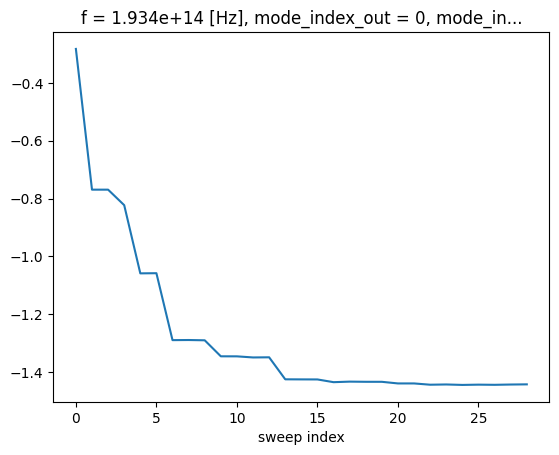

In [ ]:
(20 * np.log10(eme_sim_data.smatrix.S21.isel(mode_index_in=0, mode_index_out=0).abs)).plot()
plt.show()